In [ ]:
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

import matplotlib as mpl

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

strPath = "/content/drive/MyDrive/04_Project/DS516/jobchange/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
mpl.font_manager.fontManager.addfont(strPath+'THSarabunChula-Regular.ttf')
mpl.rc('font', family='TH Sarabun Chula')

# Data Transformation & Preprocessing

## 1. ตรวจสอบและกำหนดชนิดข้อมูล (Data Types)

In [ ]:
df = pd.read_excel("raw_data.xlsx")
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0


ปรับ Data Type ให้ถูกต้อง


In [ ]:
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

In [ ]:
df.dtypes

,0
enrollee_id,int64
city,object
city_development_index,float64
gender,object
relevent_experience,object
enrolled_university,object
education_level,object
major_discipline,object
experience,object
company_size,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  int64  
dtypes: float64(1), int64(3), object(10)
me

In [ ]:
df.select_dtypes(include='object').columns

Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',
       'company_type', 'last_new_job'],
      dtype='object')

2. ปรับข้อมูลให้ง่ายต่อการใช้งาน (Feature Transformation)


In [ ]:
df['experience'] = df['experience'].replace({
    "<1": 0,
    ">20": 21
}).infer_objects(copy=False)

/tmp/ipykernel_945/1152433498.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['experience'] = df['experience'].replace({


In [ ]:
company_size_rank = {
    'unknown': 0,
    '<10': 1,
    '10-49': 2,
    '50-99': 3,
    '100-500': 4,
    '500-999': 5,
    '1000-4999': 6,
    '5000-9999': 7,
    '10000+': 8
}

df['company_size'] = df['company_size'].fillna('unknown').map(company_size_rank)

In [ ]:
df["last_new_job"] = df["last_new_job"].replace({
    "never": 0,
    ">4": 5
}).infer_objects(copy=False)

/tmp/ipykernel_945/2212578677.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["last_new_job"] = df["last_new_job"].replace({


In [ ]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,21.0,0,NaN,1.0,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,3,Pvt Ltd,5.0,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,0,NaN,0.0,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,0,Pvt Ltd,0.0,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,21.0,3,Funded Startup,4.0,8,0


3. การจัดการ Missing Values


In [ ]:
df.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,0


In [ ]:
df['gender'] = df['gender'].fillna('unknown')

In [ ]:
df['enrolled_university'] = df['enrolled_university'].fillna('unknown')

In [ ]:
df['education_level'] = df['education_level'].fillna('unknown')

In [ ]:
df.loc[
    (df['major_discipline'].isna()) &
    (df['education_level'].isin(['Primary School','High School'])),
    'major_discipline'
] = 'No Major'

df['major_discipline'] = df['major_discipline'].fillna('unknown')

In [ ]:
df['experience'] = pd.to_numeric(df['experience'], errors='coerce').fillna(0).astype(int)

In [ ]:
df['company_size'] = df['company_size'].fillna('unknown')

In [ ]:
df['company_type'] = df['company_type'].fillna('unknown')

In [ ]:
bins = [0, 2, 5, 10, 100]
labels = ["Beginner", "Junior", "Mid", "Senior"]

df["experience_group"] = pd.cut(
    df["experience"],
    bins=bins,
    labels=labels,
    right=True
)

In [ ]:
df["last_new_job"] = pd.to_numeric(df["last_new_job"], errors="coerce")

In [ ]:
bins = [-1,2,5,10,100]
labels = ["Beginner","Junior","Mid","Senior"]

df["experience_group"] = pd.cut(df["experience"], bins=bins, labels=labels)

# group median impute
df["last_new_job"] = df["last_new_job"].fillna(
    df.groupby("experience_group", observed=False)["last_new_job"].transform("median")
)

# fallback
df["last_new_job"] = df["last_new_job"].fillna(df["last_new_job"].median())

In [ ]:
df.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,0
relevent_experience,0
enrolled_university,0
education_level,0
major_discipline,0
experience,0
company_size,0


In [ ]:
df.to_excel("clean_data.xlsx", index=False)

# EDA

In [ ]:
def chi_square_analysis(df, cat, target='target'):
    import pandas as pd
    import numpy as np
    from scipy.stats import chi2_contingency

    sub = df[[cat, target]].copy()
    sub[target] = pd.to_numeric(sub[target], errors='coerce')
    sub = sub.dropna(subset=[cat, target])
    sub[target] = sub[target].astype(int)
    sub = sub[sub[target].isin([0, 1])]
    sub[cat] = sub[cat].astype(str).str.strip()

    # ตารางไขว้
    ct = pd.crosstab(sub[cat], sub[target]).reindex(columns=[0,1], fill_value=0)

    # Chi-square
    chi2, p, dof, expected = chi2_contingency(ct.values)

    # Cramer's V
    n = ct.values.sum()
    r, k = ct.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r-1, k-1))))

    # Job-change rate
    rate = (ct[1] / ct.sum(axis=1) * 100).round(2).sort_values(ascending=False)

    print(f'===== {cat} =====')
    print('Job-change Rate (%):\n', rate)
    print('\nObserved (O):\n', ct)
    print('\nExpected (E) under H0:\n', pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(2))
    print(f'\nChi-square = {chi2:.3f}, df = {dof}, p = {p:.3e}, Cramer\'s V = {cramers_v:.3f}, N = {n}')

In [ ]:
def plot_categorical_target(df, cat, target='target'):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd

    data = df[[cat, target]].copy()

    data[target] = pd.to_numeric(data[target], errors='coerce')
    data = data.dropna(subset=[cat, target])
    data[target] = data[target].astype(int)
    data = data[data[target].isin([0,1])]

    data[cat] = data[cat].astype(str).str.strip()

    plt.figure(figsize=(7,4))

    ax = sns.countplot(
        data=data,
        x=cat,
        hue=target,
        palette='Set2'
    )

    ax.set_title(f'จำนวนผู้สมัคร แยกตาม {cat} และการเปลี่ยนงาน (target)')
    ax.set_xlabel(cat)
    ax.set_ylabel('จำนวน (คน)')
    ax.legend(title='target (0=ไม่เปลี่ยน, 1=เปลี่ยน)')

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f'{int(height):,}',
            (p.get_x()+p.get_width()/2, height),
            ha='center', va='bottom',
            fontsize=9,
            xytext=(0,3),
            textcoords='offset points'
        )

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_job_change_rate(df, col, target='target'):
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    sub = df[[col, target]].dropna().copy()
    sub[target] = pd.to_numeric(sub[target], errors='coerce')
    sub = sub.dropna(subset=[target])
    sub[target] = sub[target].astype(int)

    # คำนวณอัตราเปลี่ยนงาน (%)
    rate = (sub.groupby(col)[target].mean().sort_values(ascending=False) * 100)

    plt.figure(figsize=(6,4))
    ax = sns.barplot(x=rate.index, y=rate.values, color='#4e79a7')

    ax.set_title(f'อัตราเปลี่ยนงาน (%) ตาม {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('อัตราเปลี่ยนงาน (%)')

    # ใส่ label %
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')

    plt.ylim(0, max(rate.values)*1.15)
    plt.tight_layout()
    plt.show()

In [ ]:
def point_biserial_analysis(df, num_col, target='target'):
    from scipy.stats import pointbiserialr

    # เลือกเฉพาะตัวแปรที่ต้องใช้
    sub = df[[num_col, target]].copy()

    sub = sub.dropna()
    sub[target] = sub[target].astype(int)

    # คำนวณ Point-biserial (เหมือน Pearson สำหรับ Numeric-Binary)
    r_pb, p_value = pointbiserialr(sub[target], sub[num_col])

    print(f"===== {num_col} =====")
    print("Point-biserial r:", r_pb)
    print("p-value:", p_value)

In [ ]:
def plot_numeric_target(df, num_col, target='target'):
    import seaborn as sns
    import matplotlib.pyplot as plt

    sub = df[[num_col, target]].copy()
    sub = sub.dropna()
    sub[target] = sub[target].astype(int)

    plt.figure(figsize=(7,4))

    sns.kdeplot(
        data=sub,
        x=num_col,
        hue=target,
        fill=True,
        common_norm=False
    )

    plt.title(f'Distribution ของ {num_col} แยกตาม target')
    plt.xlabel(num_col)
    plt.ylabel('Density')

    plt.tight_layout()
    plt.show()

## 1. ค่าความสัมพันธ์ของเพศ (gender) กับการเปลี่ยนงาน (JobChange)

In [ ]:
# 1) อ่านไฟล์
df = pd.read_excel('clean_data.xlsx', engine='openpyxl')

In [ ]:
chi_square_analysis(df, 'gender')

===== gender =====
Job-change Rate (%):
 gender
unknown    30.81
Female     26.33
Other      26.18
Male       22.78
dtype: float64

Observed (O):
 target       0     1
gender              
Female     912   326
Male     10209  3012
Other      141    50
unknown   3119  1389

Expected (E) under H0:
 target         0        1
gender                   
Female    929.31   308.69
Male     9924.38  3296.62
Other     143.37    47.63
unknown  3383.94  1124.06

Chi-square = 117.377, df = 3, p = 2.833e-25, Cramer's V = 0.078, N = 19158


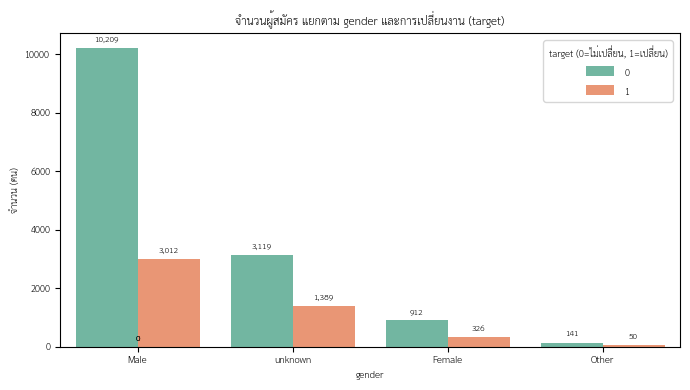

In [ ]:
plot_categorical_target(df,'gender')

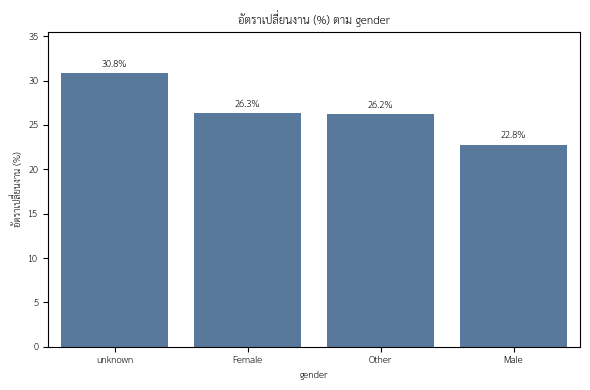

In [ ]:
plot_job_change_rate(df,'gender')

## 2. ค่าความสัมพันธ์ของค่า CDI (city_development_index) กับการเปลี่ยนงาน (JobChange)

In [ ]:
point_biserial_analysis(df, 'city_development_index')

===== city_development_index =====
Point-biserial r: -0.34166508554522845
p-value: 0.0


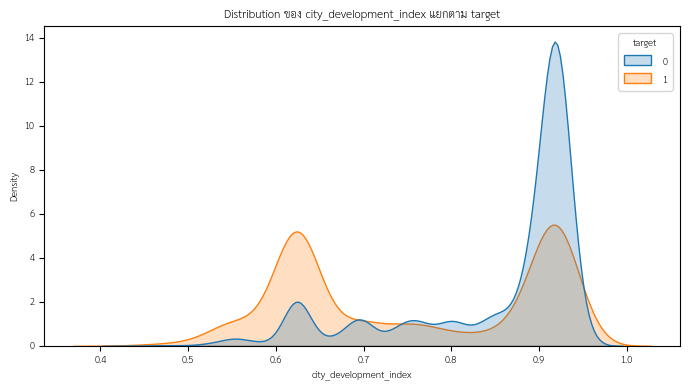

In [ ]:
plot_numeric_target(df,'city_development_index')

## 3. ค่าความสัมพันธ์ของประสบการณ์ที่เกี่ยวข้องกับงาน (relevent_experience) กับการเปลี่ยนงาน (JobChange)

In [ ]:
chi_square_analysis(df, 'relevent_experience')

===== relevent_experience =====
Job-change Rate (%):
 relevent_experience
No relevent experience     33.84
Has relevent experience    21.47
dtype: float64

Observed (O):
 target                       0     1
relevent_experience                 
Has relevent experience  10831  2961
No relevent experience    3550  1816

Expected (E) under H0:
 target                         0       1
relevent_experience                     
Has relevent experience  10353.0  3439.0
No relevent experience    4028.0  1338.0

Chi-square = 315.339, df = 1, p = 1.501e-70, Cramer's V = 0.128, N = 19158


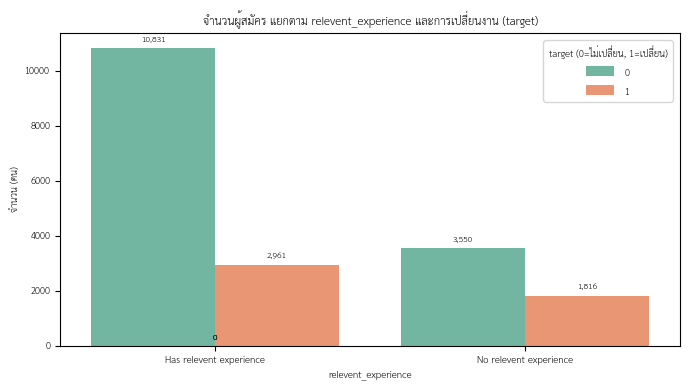

In [ ]:
plot_categorical_target(df,'relevent_experience')

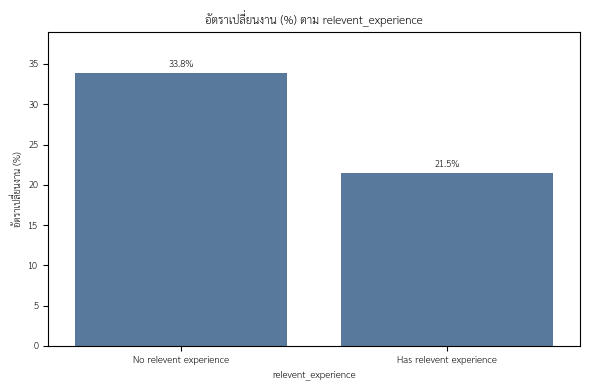

In [ ]:
plot_job_change_rate(df,'relevent_experience')

## 4. ค่าความสัมพันธ์ของสถานะการศึกษา(enrolled_university) กับการเปลี่ยนงาน (JobChange)

In [ ]:
chi_square_analysis(df, 'enrolled_university')

===== enrolled_university =====
Job-change Rate (%):
 enrolled_university
Full time course    38.09
unknown             31.87
Part time course    25.21
no_enrollment       21.14
dtype: float64

Observed (O):
 target                   0     1
enrolled_university             
Full time course      2326  1431
Part time course       896   302
no_enrollment        10896  2921
unknown                263   123

Expected (E) under H0:
 target                      0        1
enrolled_university                   
Full time course      2820.20   936.80
Part time course       899.28   298.72
no_enrollment        10371.77  3445.23
unknown                289.75    96.25

Chi-square = 463.534, df = 3, p = 3.809e-100, Cramer's V = 0.156, N = 19158


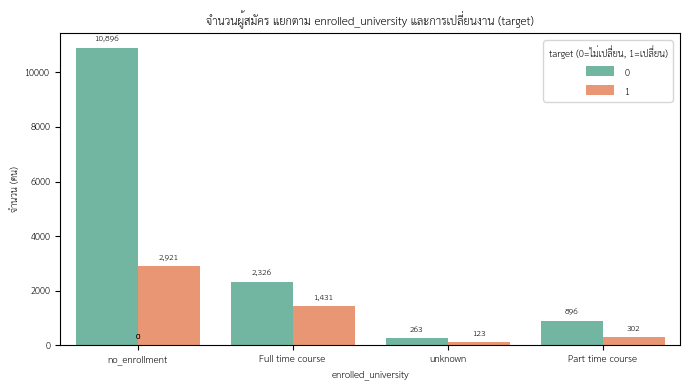

In [ ]:
plot_categorical_target(df,'enrolled_university')

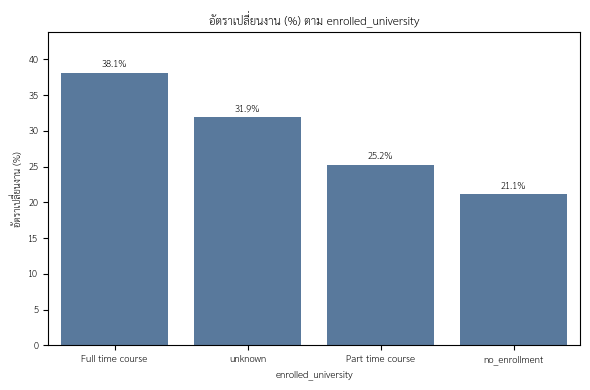

In [ ]:
plot_job_change_rate(df,'enrolled_university')

## 5. ค่าความสัมพันธ์ของระดับการศึกษา (education_level) กับการเปลี่ยนงาน (JobChange)

In [ ]:
chi_square_analysis(df, 'education_level')

===== education_level =====
Job-change Rate (%):
 education_level
Graduate          27.98
unknown           22.61
Masters           21.44
High School       19.53
Phd               14.01
Primary School    13.31
dtype: float64

Observed (O):
 target              0     1
education_level            
Graduate         8353  3245
High School      1623   394
Masters          3426   935
Phd               356    58
Primary School    267    41
unknown           356   104

Expected (E) under H0:
 target                 0        1
education_level                  
Graduate         8706.07  2891.93
High School      1514.07   502.93
Masters          3273.60  1087.40
Phd               310.77   103.23
Primary School    231.20    76.80
unknown           345.30   114.70

Chi-square = 167.271, df = 5, p = 2.787e-34, Cramer's V = 0.093, N = 19158


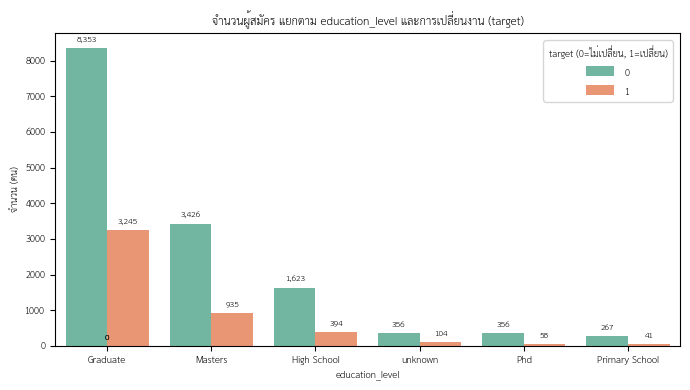

In [ ]:
plot_categorical_target(df,'education_level')

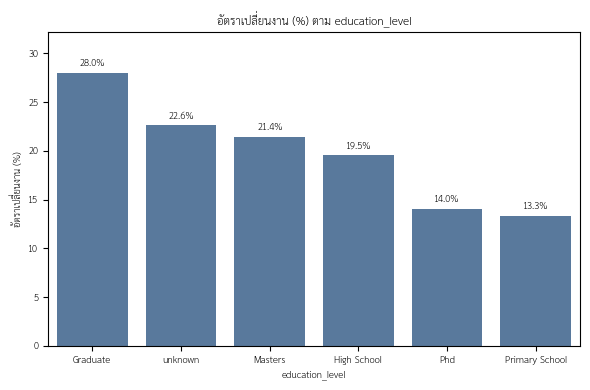

In [ ]:
plot_job_change_rate(df,'education_level')

## 6. ค่าความสัมพันธ์ของสาขาที่จบ (major_discipline) กับการเปลี่ยนงาน (JobChange)

In [ ]:
chi_square_analysis(df, 'major_discipline')

===== major_discipline =====
Job-change Rate (%):
 major_discipline
Other              26.77
Business Degree    26.30
STEM               26.16
unknown            23.36
Humanities         21.08
Arts               20.95
No Major           19.23
dtype: float64

Observed (O):
 target                0     1
major_discipline             
Arts                200    53
Business Degree     241    86
Humanities          528   141
No Major           2058   490
Other               279   102
STEM              10701  3791
unknown             374   114

Expected (E) under H0:
 target                   0        1
major_discipline                   
Arts                189.92    63.08
Business Degree     245.46    81.54
Humanities          502.19   166.81
No Major           1912.66   635.34
Other               286.00    95.00
STEM              10878.46  3613.54
unknown             366.32   121.68

Chi-square = 65.027, df = 6, p = 4.259e-12, Cramer's V = 0.058, N = 19158


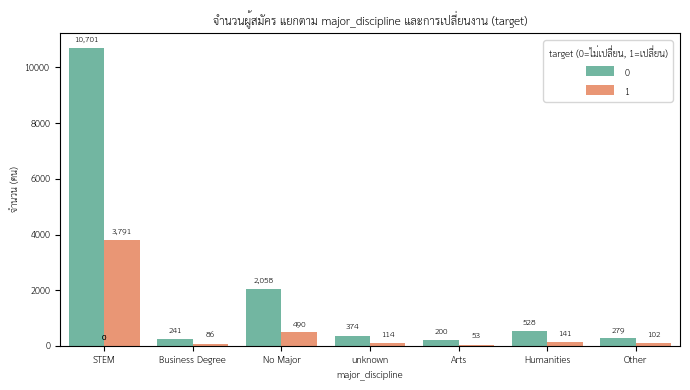

In [ ]:
plot_categorical_target(df,'major_discipline')

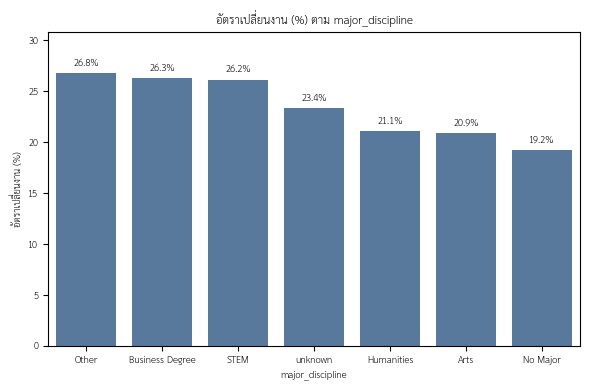

In [ ]:
plot_job_change_rate(df,'major_discipline')

## 7. ค่าความสัมพันธ์ของสบการณ์การทำงาน (experience) กับการเปลี่ยนงาน (JobChange)

In [ ]:
point_biserial_analysis(df, 'experience')

===== experience =====
Point-biserial r: -0.17689770052707882
p-value: 1.8382569236246635e-134


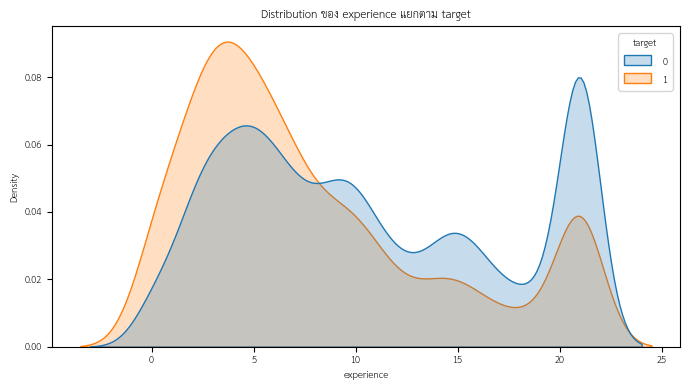

In [ ]:
plot_numeric_target(df,'experience')

## 8. ค่าความสัมพันธ์ของขนาดของบริษัท (company_size) กับการเปลี่ยนงาน (JobChange)

In [ ]:
point_biserial_analysis(df, 'company_size')

===== company_size =====
Point-biserial r: -0.1827710858384665
p-value: 1.4767435542352926e-143


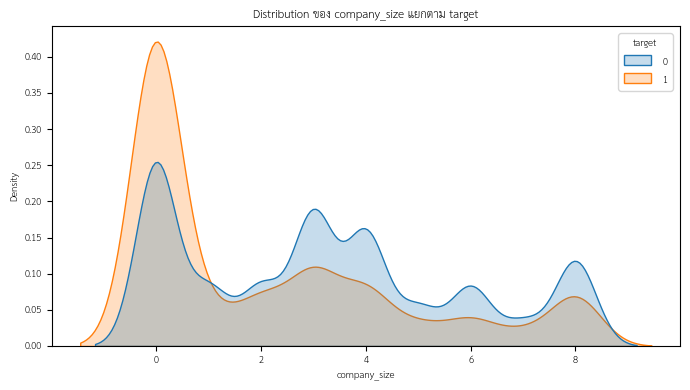

In [ ]:
plot_numeric_target(df,'company_size')

## 9. ค่าความสัมพันธ์ของประเภทของบริษัท (company_type) กับการเปลี่ยนงาน (JobChange)

In [ ]:
chi_square_analysis(df, 'major_discipline')
(df, 'company_type')

===== major_discipline =====
Job-change Rate (%):
 major_discipline
Other              26.77
Business Degree    26.30
STEM               26.16
unknown            23.36
Humanities         21.08
Arts               20.95
No Major           19.23
dtype: float64

Observed (O):
 target                0     1
major_discipline             
Arts                200    53
Business Degree     241    86
Humanities          528   141
No Major           2058   490
Other               279   102
STEM              10701  3791
unknown             374   114

Expected (E) under H0:
 target                   0        1
major_discipline                   
Arts                189.92    63.08
Business Degree     245.46    81.54
Humanities          502.19   166.81
No Major           1912.66   635.34
Other               286.00    95.00
STEM              10878.46  3613.54
unknown             366.32   121.68

Chi-square = 65.027, df = 6, p = 4.259e-12, Cramer's V = 0.058, N = 19158


(       enrollee_id      city  city_development_index   gender  \
 0             8949  city_103                   0.920     Male   
 1            29725   city_40                   0.776     Male   
 2            11561   city_21                   0.624  unknown   
 3            33241  city_115                   0.789  unknown   
 4              666  city_162                   0.767     Male   
 ...            ...       ...                     ...      ...   
 19153         7386  city_173                   0.878     Male   
 19154        31398  city_103                   0.920     Male   
 19155        24576  city_103                   0.920     Male   
 19156         5756   city_65                   0.802     Male   
 19157        23834   city_67                   0.855  unknown   
 
            relevent_experience enrolled_university education_level  \
 0      Has relevent experience       no_enrollment        Graduate   
 1       No relevent experience       no_enrollment        Gradu

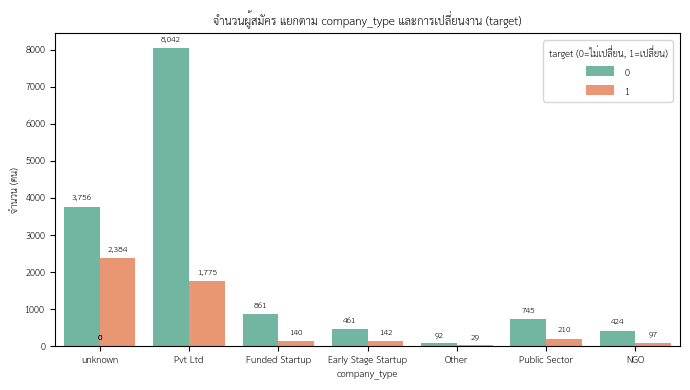

In [ ]:
plot_categorical_target(df,'company_type')

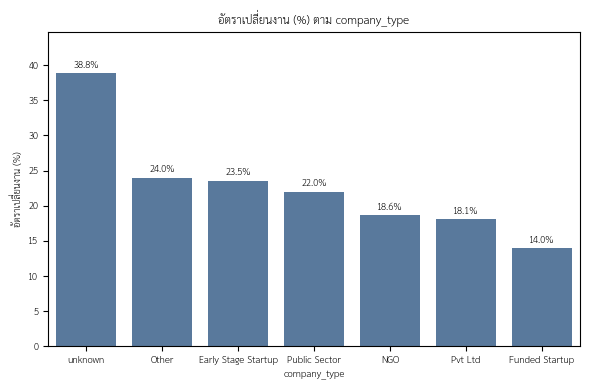

In [ ]:
plot_job_change_rate(df,'company_type')

## 10. ค่าความสัมพันธ์ของระยะเวลาการทำงานของงานล่าสุด (last_new_job) กับการเปลี่ยนงาน (JobChange)

In [ ]:
point_biserial_analysis(df, 'last_new_job')

===== last_new_job =====
Point-biserial r: -0.08493355271650366
p-value: 5.166772010693058e-32


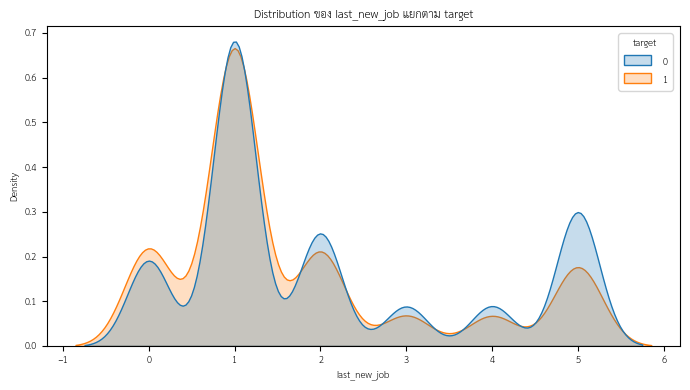

In [ ]:
plot_numeric_target(df,'last_new_job')

## 11. ค่าความสัมพันธ์ของจำนวนชั่วโมงของการฝึกอบรม (training_hours) กับการเปลี่ยนงาน (JobChange)

In [ ]:
point_biserial_analysis(df, 'training_hours')

===== training_hours =====
Point-biserial r: -0.021577249713613245
p-value: 0.002819949452636186


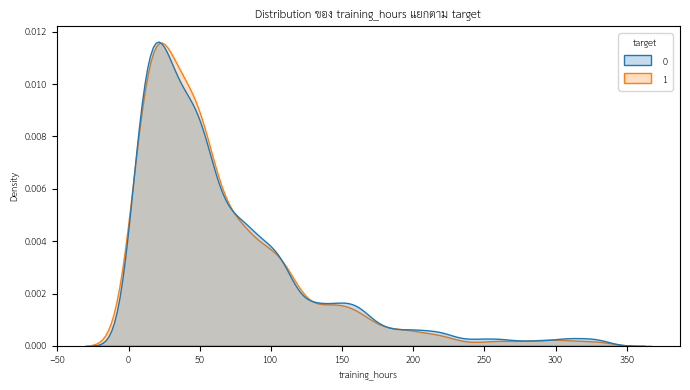

In [ ]:
plot_numeric_target(df,'training_hours')

# Encode

In [ ]:
dataset  = df.copy()

In [ ]:
dataset = dataset[
[
'company_size',
'company_type',
'city_development_index',
'experience',
'enrolled_university',
'relevent_experience',
'education_level',
'gender',
'major_discipline',
'last_new_job',
'training_hours',
'target'
]
]
dataset.head()

,company_size,company_type,city_development_index,experience,enrolled_university,relevent_experience,education_level,gender,major_discipline,last_new_job,training_hours,target
0,0,unknown,0.920,21,no_enrollment,Has relevent experience,Graduate,Male,STEM,1,36,1
1,3,Pvt Ltd,0.776,15,no_enrollment,No relevent experience,Graduate,Male,STEM,5,47,0
2,0,unknown,0.624,5,Full time course,No relevent experience,Graduate,unknown,STEM,0,83,0
3,0,Pvt Ltd,0.789,0,unknown,No relevent experience,Graduate,unknown,Business Degree,0,52,1
4,3,Funded Startup,0.767,21,no_enrollment,Has relevent experience,Masters,Male,STEM,4,8,0


In [ ]:
# 1. company_type
dataset['company_type'] = dataset['company_type'].map({
    'unknown':0,
    'Other':1,
    'NGO':2,
    'Public Sector':3,
    'Early Stage Startup':4,
    'Funded Startup':5,
    'Pvt Ltd':6
})

 # 2. enrolled_university
dataset['enrolled_university'] = dataset['enrolled_university'].map({
    'unknown': 0,
    'no_enrollment': 1,
    'Part time course': 2,
    'Full time course': 3
})

# 3. relevent_experience
dataset['relevent_experience'] = dataset['relevent_experience'].map({
    'No relevent experience':0,
    'Has relevent experience':1
})

# 4. education_level
dataset['education_level'] = dataset['education_level'].map({
    'unknown':0,
    'Primary School':1,
    'High School':2,
    'Graduate':3,
    'Masters':4,
    'Phd':5
})

# 5. gender
dataset['gender'] = dataset['gender'].map({
    'unknown': 0,
    'Male': 1,
    'Female': 2,
    'Other': 3
})

# 6. major_discipline
dataset['major_discipline'] = dataset['major_discipline'].map({
    'unknown':0,
    'STEM':1,
    'Business Degree':2,
    'Arts':3,
    'Humanities':4,
    'No Major':4,
    'Other':6
})

dataset.head()

,company_size,company_type,city_development_index,experience,enrolled_university,relevent_experience,education_level,gender,major_discipline,last_new_job,training_hours,target
0,0,0,0.920,21,1,1,3,1,1,1,36,1
1,3,6,0.776,15,1,0,3,1,1,5,47,0
2,0,0,0.624,5,3,0,3,0,1,0,83,0
3,0,6,0.789,0,0,0,3,0,2,0,52,1
4,3,5,0.767,21,1,1,4,1,1,4,8,0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_size            19158 non-null  int64  
 1   company_type            19158 non-null  int64  
 2   city_development_index  19158 non-null  float64
 3   experience              19158 non-null  int64  
 4   enrolled_university     19158 non-null  int64  
 5   relevent_experience     19158 non-null  int64  
 6   education_level         19158 non-null  int64  
 7   gender                  19158 non-null  int64  
 8   major_discipline        19158 non-null  int64  
 9   last_new_job            19158 non-null  int64  
 10  training_hours          19158 non-null  int64  
 11  target                  19158 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 1.8 MB


# **Train Model**

In [ ]:
X = dataset.drop('target', axis=1)
y = dataset['target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(15326, 11)
(3832, 11)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(15326, 11)
(3832, 11)


# Logistic Regression



In [ ]:
param_grid = {
    'penalty': ['l1','l2'],
    'C': [0.01,0.1,1,10],
    'solver': ['liblinear']
}

model = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1'
)

model.fit(X_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='f1')

In [ ]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))

print("ROC AUC:", roc_auc_score(y_test,y_prob))

print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.7152922755741128
Precision: 0.4531355360755226
Recall: 0.7058823529411765
F1 Score: 0.5519507186858317
ROC AUC: 0.7629208975256769
Confusion Matrix
[[2069  811]
 [ 280  672]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.72      0.79      2880
           1       0.45      0.71      0.55       952

    accuracy                           0.72      3832
   macro avg       0.67      0.71      0.67      3832
weighted avg       0.77      0.72      0.73      3832



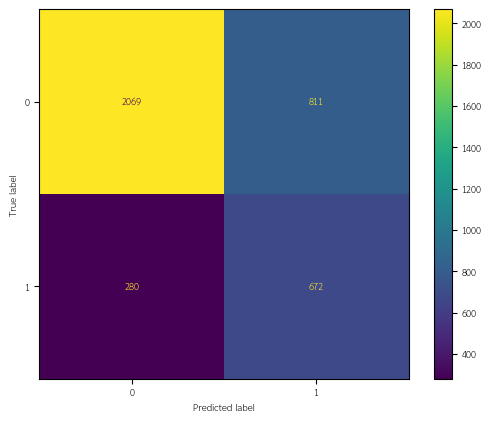

In [ ]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

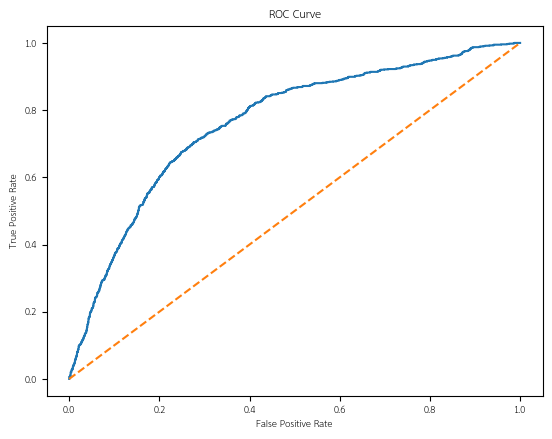

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# Logistic Regression NO CV

In [ ]:
model_no_cv = LogisticRegression(max_iter=1000, class_weight='balanced')
model_no_cv.fit(X_train_scaled, y_train)

y_pred_no_cv = model_no_cv.predict(X_test_scaled)
y_prob_no_cv = model.predict_proba(X_test_scaled)[:,1]


print("F1 Score (No CV):", f1_score(y_test, y_pred_no_cv))
print(classification_report(y_test, y_pred_no_cv))

F1 Score (No CV): 0.5519507186858317
              precision    recall  f1-score   support

           0       0.88      0.72      0.79      2880
           1       0.45      0.71      0.55       952

    accuracy                           0.72      3832
   macro avg       0.67      0.71      0.67      3832
weighted avg       0.77      0.72      0.73      3832



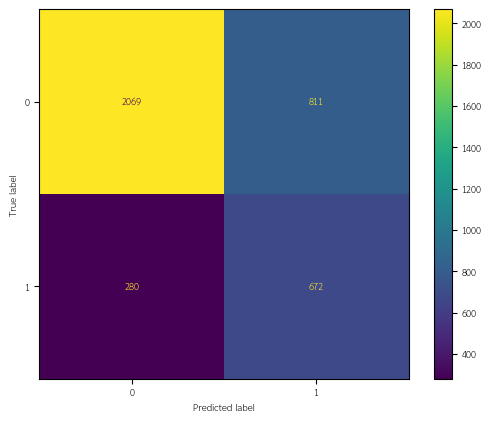

In [ ]:
cm = confusion_matrix(y_test, y_pred_no_cv)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

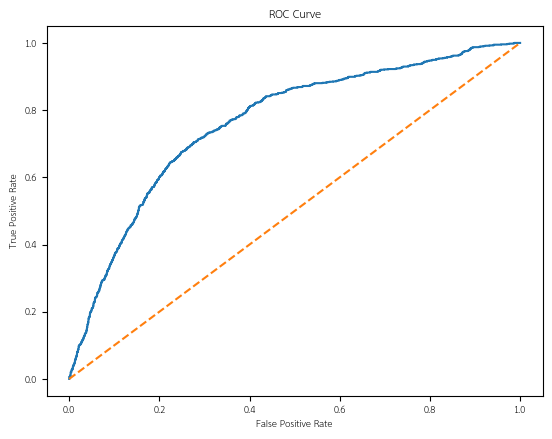

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_no_cv)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression (No CV)", "Logistic Regression (CV)"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_no_cv),
        accuracy_score(y_test, y_pred)
    ],

    "Precision": [
        precision_score(y_test, y_pred_no_cv),
        precision_score(y_test, y_pred)
    ],

    "Recall": [
        recall_score(y_test, y_pred_no_cv),
        recall_score(y_test, y_pred)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_no_cv),
        f1_score(y_test, y_pred)
    ],

    "ROC AUC": [
        roc_auc_score(y_test, y_prob_no_cv),
        roc_auc_score(y_test, y_prob)
    ]
})

print(results)

                         Model  Accuracy  Precision    Recall  F1 Score  \
0  Logistic Regression (No CV)  0.715292   0.453136  0.705882  0.551951   
1     Logistic Regression (CV)  0.715292   0.453136  0.705882  0.551951   

    ROC AUC  
0  0.762921  
1  0.762921  


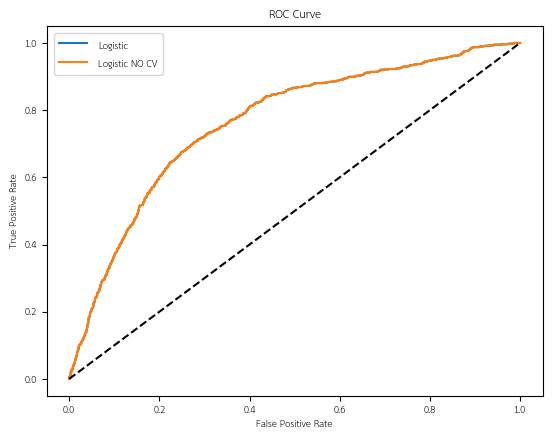

In [ ]:
# cv
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)

# NO CV
fpr_svm, tpr_svm, _ = roc_curve(y_test,y_prob_no_cv)

plt.plot(fpr_lr, tpr_lr, label="Logistic")
plt.plot(fpr_svm, tpr_svm, label="Logistic NO CV")

plt.plot([0,1],[0,1],'k--')  # เส้น random
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# SVM (Support Vector Machine)

In [ ]:
param_grid = {
    'kernel': ['linear','rbf'],
    'C': [1,10]
}
svm_model = GridSearchCV(
    SVC(class_weight='balanced', probability=True),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
svm_model.fit(X_train_scaled, y_train)

GridSearchCV(cv=3, estimator=SVC(class_weight='balanced', probability=True),
             n_jobs=-1, param_grid={'C': [1, 10], 'kernel': ['linear', 'rbf']},
             scoring='f1')

In [ ]:
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
print(y_pred_svm[:20])

[0 0 0 1 1 0 0 1 1 0 0 1 1 1 0 0 0 1 0 0]


In [ ]:
from sklearn.metrics import f1_score

print(f1_score(y_test, y_pred_svm))

0.5987628865979382


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)
print(cm)

[[2133  747]
 [ 226  726]]


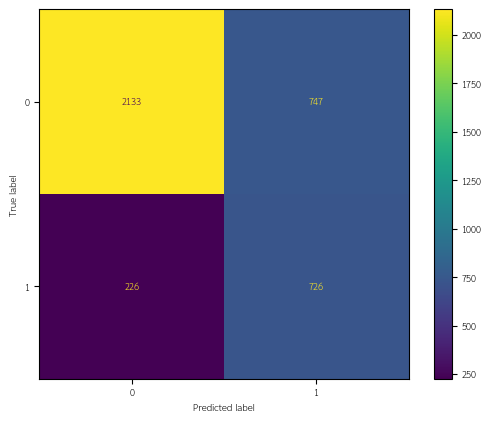

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      2880
           1       0.49      0.76      0.60       952

    accuracy                           0.75      3832
   macro avg       0.70      0.75      0.71      3832
weighted avg       0.80      0.75      0.76      3832



In [112]:
auc = roc_auc_score(y_test, y_pred_svm)
print("AUC:", auc)

AUC: 0.7516150210084034


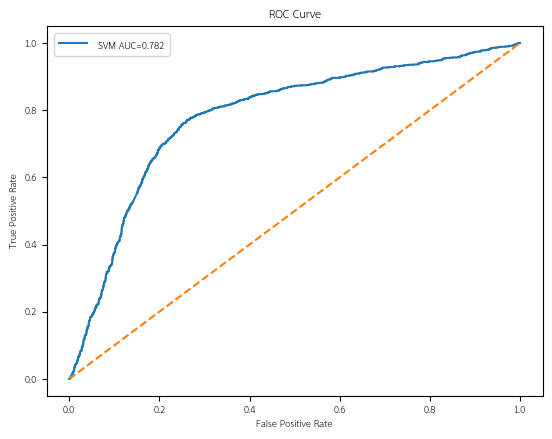

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
auc = roc_auc_score(y_test, y_prob_svm)

plt.plot(fpr, tpr, label="SVM AUC=" + str(round(auc,3)))
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# SVM NO CV

In [ ]:
svm_no_cv = SVC(
    kernel='linear',
    class_weight='balanced',
    probability=True
)

svm_no_cv.fit(X_train_scaled, y_train)

y_pred_svm_no_cv = svm_no_cv.predict(X_test_scaled)
y_prob_svm_no_cv = svm_no_cv.predict_proba(X_test_scaled)[:,1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1:", f1_score(y_test, y_pred_svm))

print('no cv')
print("Accuracy:", accuracy_score(y_test, y_pred_svm_no_cv))
print("Precision:", precision_score(y_test, y_pred_svm_no_cv))
print("Recall:", recall_score(y_test, y_pred_svm_no_cv))
print("F1:", f1_score(y_test, y_pred_svm_no_cv))

Accuracy: 0.7460855949895616
Precision: 0.49287169042769857
Recall: 0.7626050420168067
F1: 0.5987628865979382
no cv
Accuracy: 0.7184237995824635
Precision: 0.4544149318018665
Recall: 0.6649159663865546
F1: 0.5398720682302772


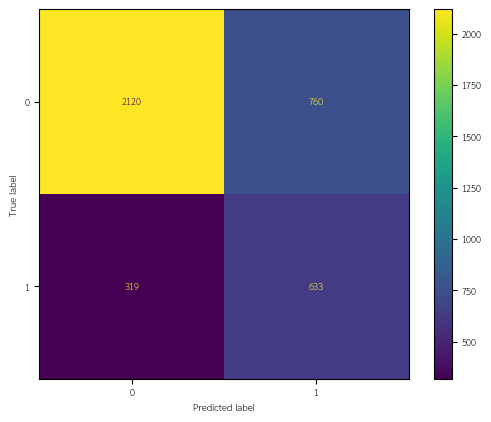

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm_no_cv)

In [ ]:
print(classification_report(y_test, y_pred_svm_no_cv))

              precision    recall  f1-score   support

           0       0.87      0.74      0.80      2880
           1       0.45      0.66      0.54       952

    accuracy                           0.72      3832
   macro avg       0.66      0.70      0.67      3832
weighted avg       0.77      0.72      0.73      3832



In [111]:
auc = roc_auc_score(y_test, y_pred_svm_no_cv)
print("AUC:", auc)

AUC: 0.7005135387488328


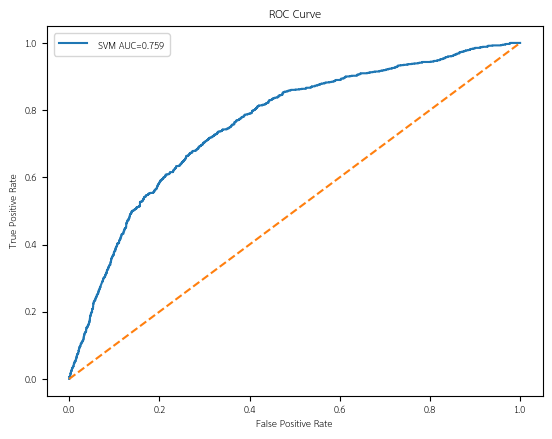

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_svm_no_cv)
auc = roc_auc_score(y_test, y_prob_svm_no_cv)

plt.plot(fpr, tpr, label="SVM AUC=" + str(round(auc,3)))
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# เปรียบเทียบ model svm  Vs svm no cv

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

results = pd.DataFrame({
    "Model": ["SVM","SVM NO CV"],
    "Accuracy":[
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_svm_no_cv)
    ],
    "F1":[
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm_no_cv)
    ]
})

print(results)

       Model  Accuracy        F1
0        SVM  0.746086  0.598763
1  SVM NO CV  0.718424  0.539872


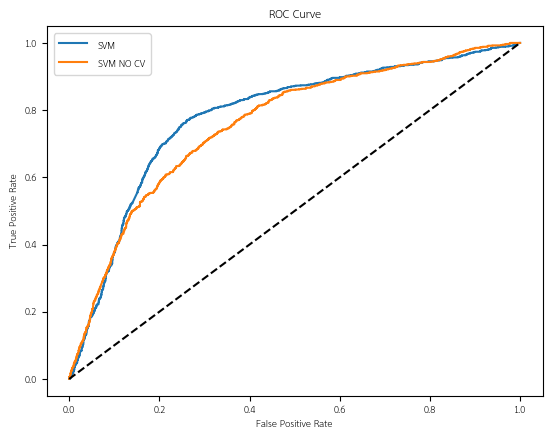

In [ ]:
# SVM
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_svm)

# SVM NO CV
fpr_svm, tpr_svm, _ = roc_curve(y_test,y_prob_svm_no_cv)

plt.plot(fpr_lr, tpr_lr, label="SVM")
plt.plot(fpr_svm, tpr_svm, label="SVM NO CV")

plt.plot([0,1],[0,1],'k--')  # เส้น random
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

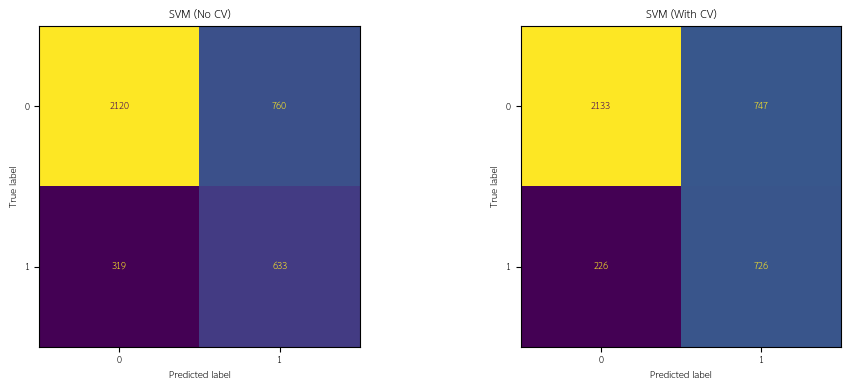

In [109]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

# ซ้าย: SVM (No CV)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_no_cv,
    ax=ax[0],
    colorbar=False
)
ax[0].set_title("SVM (No CV)")

# ขวา: SVM (With CV)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    ax=ax[1],
    colorbar=False
)
ax[1].set_title("SVM (With CV)")

plt.tight_layout()
plt.show()

# เปรียบเทียบ model ทั้ง 4 แบบ

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

results = pd.DataFrame({
    "Model": ["Logistic Regression","Logistic Regression NO CV","SVM","SVM NO CV"],
    "Accuracy":[
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_no_cv),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_svm_no_cv)
    ],
    "F1":[
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_no_cv),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm_no_cv)
    ],

     "Recall":[
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_no_cv),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_svm_no_cv)
    ],

})

print(results)

                       Model  Accuracy        F1    Recall
0        Logistic Regression  0.715292  0.551951  0.705882
1  Logistic Regression NO CV  0.715292  0.551951  0.705882
2                        SVM  0.746086  0.598763  0.762605
3                  SVM NO CV  0.718424  0.539872  0.664916


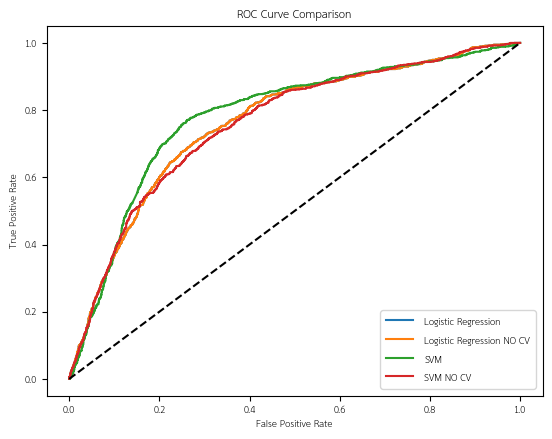

In [ ]:
# Logistic
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)

# Logistic NO CV
fpr_lr_no_cv, tpr_lr_no_cv, _ = roc_curve(y_test, y_prob_no_cv)

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

# SVM NO CV
fpr_svm_no_cv, tpr_svm_no_cv, _ = roc_curve(y_test, y_prob_svm_no_cv)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_lr_no_cv, tpr_lr_no_cv, label="Logistic Regression NO CV")
plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.plot(fpr_svm_no_cv, tpr_svm_no_cv, label="SVM NO CV")

plt.plot([0,1],[0,1],'k--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

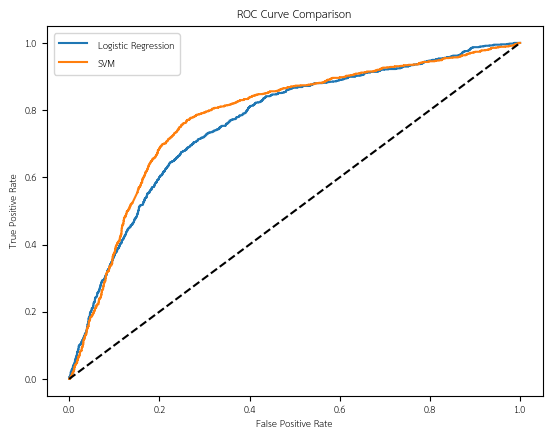

In [110]:
# Logistic BEST
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)

# SVM BEST
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_svm, tpr_svm, label="SVM")

plt.plot([0,1],[0,1],'k--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()